# Tutorial 6: Identifying Optimal Design with Low LCOE (`module_lcoe_optimizer`)
This tutorial provides an example on how to use brute force optimazation to find optimal feasible design with lowest lcoe in the desired design space. 

1. **Retrieve Tidal Data**  
   Retrieve tidal data using the `process_tidal_data` function. This provides flow speeds, time steps, and mooring distance for the simulation.

/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#t

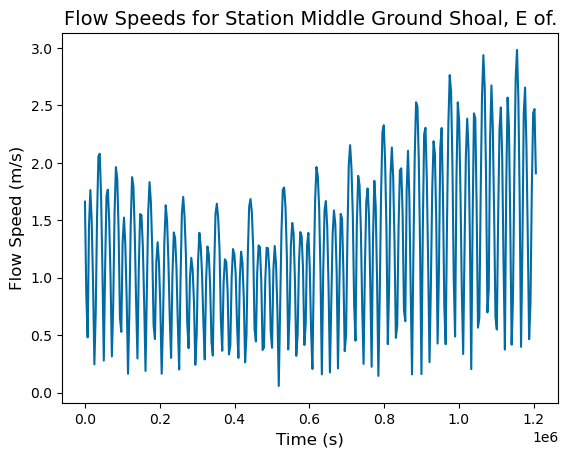

In [ ]:
from vital.module_tidal import process_tidal_data
import matplotlib.pyplot as plt
import urllib3

# Suppress InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
# Tidal data processing
station = "COI1210"  # NOAA station identifier
startdate = "2020-01-01"  # Start date for tidal data retrieval
tidal = process_tidal_data(station=station, startdate=startdate)

# Visualize tidal flow speeds
plt.figure()
plt.plot(tidal.times, tidal.flow_speeds)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Flow Speed (m/s)", fontsize=12)
plt.title(f"Flow Speeds for Station {tidal.station_name}", fontsize=14)
plt.show()

2. **Retrieve Rotor Data**  
   Retrieve rotor data.

In [2]:
from vital.module_rotor import RotorData

# Rotor data processing
RotorPerformanceFile = "../data/Sitkana_rotor_data_blade_2.txt"
rotor = RotorData(RotorPerformanceFile)

print("Rotor Data:")
print(f"  Optimal Cp: {rotor.CpOpt}")
print(f"  Optimal TSR: {rotor.TSROpt}")

Rotor Data:
  Optimal Cp: 0.21189
  Optimal TSR: 0.76477


3. **Simulation Configuration and Rotor Simulation**  
   Define the configuration parameters required for simulating rotor performance. Use these parameters to simulate the rotor's behavior under tidal flow conditions.

In [ ]:
import numpy as np
config = {
    'Radius': 0.5,
    'Prated': 5000.0,
    'Trated': np.inf,
    'dHub': 7.0,
    'number_of_turbines': 2,
    'dMoor': tidal.mooring_distance,
    'Uinf': tidal.flow_speeds,
    't': tidal.times,
    'CpFunc': rotor.get_cp,
    'CqFunc': rotor.get_cq,
    'CtFunc': rotor.get_ct,
    'CpOpt': rotor.CpOpt,
    'TSROpt': rotor.TSROpt,
    'TSRmax': rotor.TSRmax,
    'Ng': 50,
    'Kt': 1.5,
    'Rw': 0.5,
    'J_d': 1,
    'B_d': 1,
    'J_r': 10,
}

from vital.module_rotor_simulation import RotorSimulation

# Rotor simulation
rotor_sim = RotorSimulation(config)
rotor_sim.simulate()
result = rotor_sim.get_results() 

Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.


4. **Vessel Data Processing**  
   Define vessel properties for the simulation.

In [5]:
from vital.module_vessel import VesselData

user_vessel_properties = {
    'Xm': 5.77,
    'Zm': 1.65,
    'Kphi': 1.95e6,
    'theta': np.radians(45.0),
    'phi': np.radians(20.0),
    'area': 9.5,
    'Cd': 1.0,
}

vessel = VesselData(
    user_defined=True,
    vessel_properties=user_vessel_properties,
    simResult=result
)

5. **Constraint Checking**  
   Verify system constraints (e.g., power, depth, cavitation, pitch).

In [6]:
from vital.module_constraint_checker import ConstraintChecker

constraint_checker = ConstraintChecker(rotor, config, vessel, result)
constraints = {
    "Power Constraint": constraint_checker.check_power_constraint(),
    "Depth Constraint": constraint_checker.check_depth_constraint(),
    "Cavitation Constraint": constraint_checker.check_cavitation_constraint(),
    "Pitch Constraint": constraint_checker.check_pitch_constraint(),
}

print("Constraint Results:")
for name, satisfied in constraints.items():
    print(f"  {name}: {'Satisfied' if satisfied else 'Not Satisfied'}")

Constraint Results:
  Power Constraint: Not Satisfied
  Depth Constraint: Satisfied
  Cavitation Constraint: Satisfied
  Pitch Constraint: Satisfied


6. **LCOE Calculation**  
   Calculate the Levelized Cost of Energy (LCOE).

In [8]:
from vital.module_lcoe import LCOEData, LCOECalculator

data = LCOEData(
    tidal, config, vessel, result,
    lifetime=10,
    discount_rate=0.1,
    turbulence_intensity=0.0,
    customer='customer_B',
    application='battery_charging',
    BatteryCapacity_kWh=10.0
)
calculator = LCOECalculator(data) 

lcoe = calculator.calculate_lcoe()
print(f"LCOE: {lcoe:.2f}")

LCOE: 7573.73


7. **Optimization**  
   Optimize system parameters to minimize LCOE.

Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...

Solving the initial value problem (IVP) for turbine dynamics...Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...

Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) for turbine dynamics...
Solving the initial value problem (IVP) 

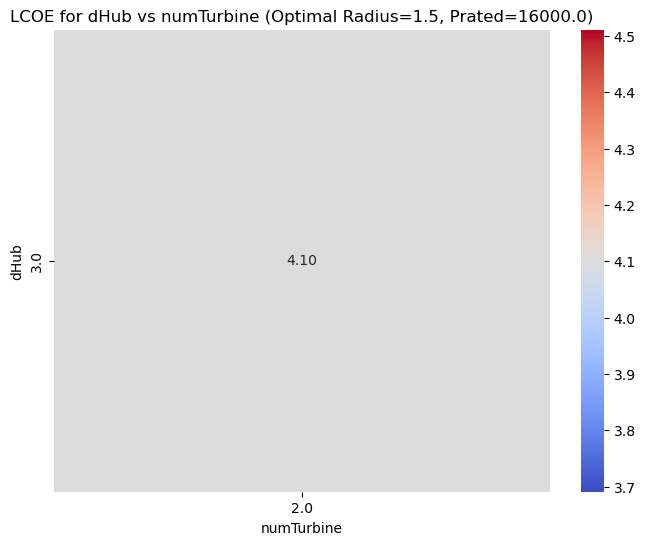

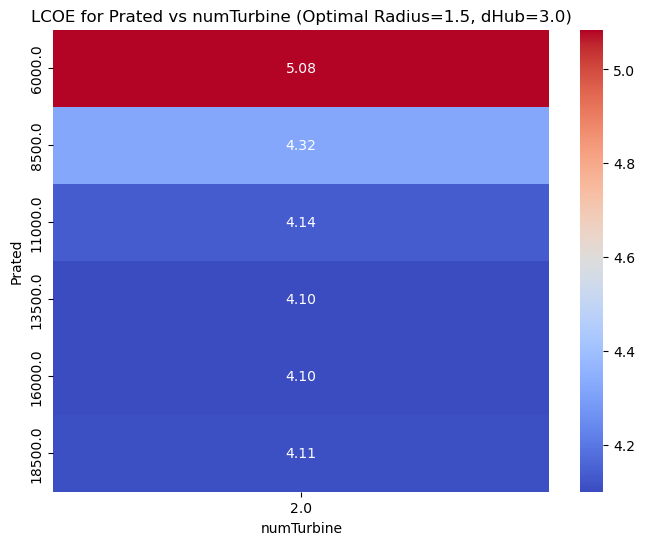

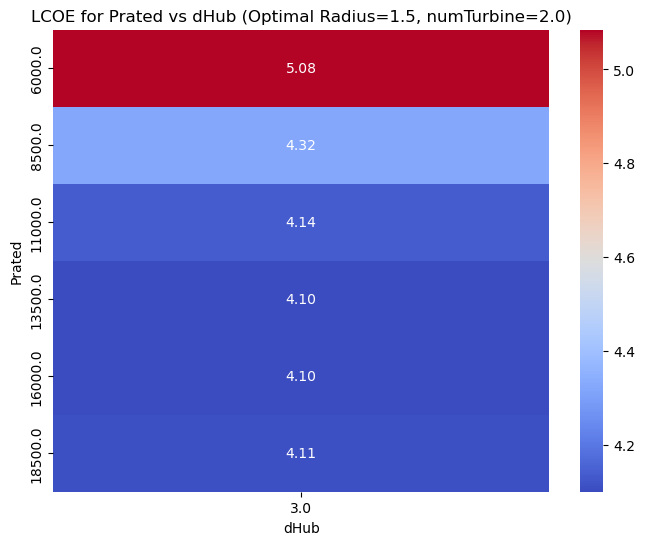

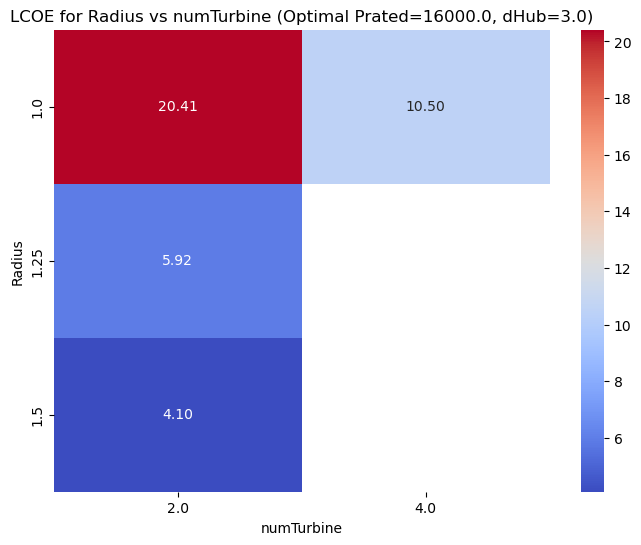

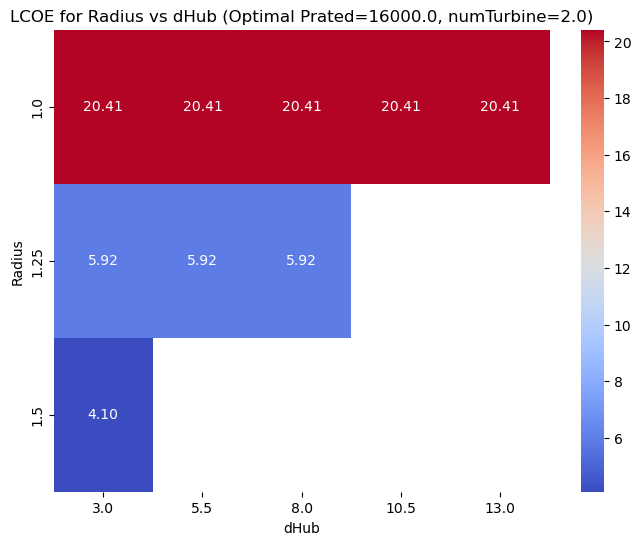

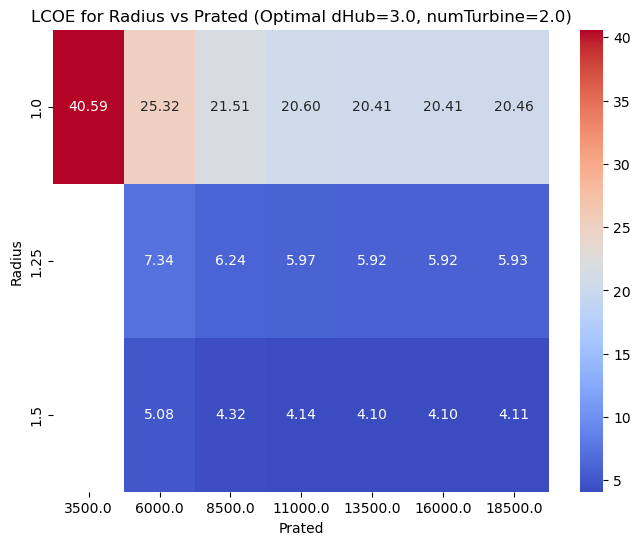

In [11]:
from vital.module_lcoe_optimizer import LCOEOptimizer

bounds = {
    'Radius': (1, 2.5, 0.25),
    'Prated': (1000.0, 20000.0, 2500.0),
    'dHub': (3, 14, 2.5),
    'numTurbine': (2, 7, 2)
}

optimizer = LCOEOptimizer(tidal, rotor, config, user_vessel_properties)
optimal_params, optimal_lcoe, brute_output = optimizer.optimize(bounds)
optimizer.plot_heatmaps(brute_output, bounds)